In [107]:
import pandas as pd

import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use('default')

import plotly
import plotly.express as px

import seaborn as sns

churn_data = pd.read_csv('data/churn.csv')
churn_data.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [108]:
churn_data = churn_data.drop('RowNumber', axis=1)
churn_data.head()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [109]:
churn_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerId       10000 non-null  int64  
 1   Surname          10000 non-null  object 
 2   CreditScore      10000 non-null  int64  
 3   Geography        10000 non-null  object 
 4   Gender           10000 non-null  object 
 5   Age              10000 non-null  int64  
 6   Tenure           10000 non-null  int64  
 7   Balance          10000 non-null  float64
 8   NumOfProducts    10000 non-null  int64  
 9   HasCrCard        10000 non-null  int64  
 10  IsActiveMember   10000 non-null  int64  
 11  EstimatedSalary  10000 non-null  float64
 12  Exited           10000 non-null  int64  
dtypes: float64(2), int64(8), object(3)
memory usage: 1015.8+ KB


In [110]:
#mask_1 = churn_data['Exited'] == 1
#mask_2 = churn_data['Exited'] == 0
#total_loyal = churn_data[mask_1]
#print(total_loyal)


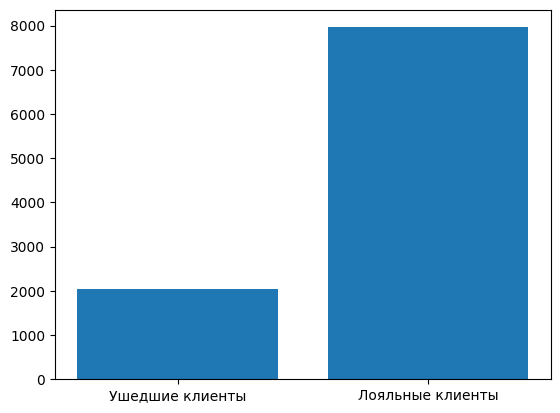

In [111]:
mask_1 = churn_data['Exited'] == 1
mask_2 = churn_data['Exited'] == 0
clients_left = churn_data['Exited'][mask_1].count()
clients_loyal = churn_data['Exited'][mask_2].count()

names = ['Ушедшие клиенты', 'Лояльные клиенты']
values = [clients_left, clients_loyal]
plt.bar(names, values)
plt.show()

In [112]:
mask_balance = churn_data['Balance'] > 2500

fig = px.histogram(
    data_frame = churn_data[mask_balance],
    x = 'Balance',
    title = 'Распределение баланса пользователей, у которых на счету больше 2 500 долларов',
    labels = {'Balance': 'Баланс (в долларах)', 'count':'количество клиентов'},
)

fig.show()

    

9.3. Посмотрите на распределение баланса клиента в разрезе признака оттока. Как различаются суммы на накопительном счёте ушедших и лояльных клиентов? Подумайте и напишите, с чем это может быть связано, что может не устраивать ушедших клиентов в банке.

In [113]:
churn_data['IsActiveMember'] = churn_data['IsActiveMember'].apply(lambda x: 'Неактивный' if x == 0 else 'Активный')
churn_data['Exited'] = churn_data['Exited'].apply(lambda x: 'Лояльный' if x == 0 else 'Ушедший')

fig = px.histogram(churn_data,
    x = 'Balance',
    nbins = 20,
    title = 'Распределение баланса клиентов по оттоку',
    color = 'Exited',
    histnorm = 'percent',
    color_discrete_sequence=['red', 'turquoise'], 
    
    opacity=1,
    height=500,
    width=1000,
    
)
fig.update_xaxes(title_text='Баланс')
fig.update_yaxes(title_text='Количество клиентов')

fig.show()

Средний баланс ушедших клиентов значительно превышал баланс лояльных. Причина вероятно в том, что клиентов переманили конкурирующие банки с более выгодными условиями размещения вкладов.

9.4. Посмотрите на распределение возраста в разрезе признака оттока. В какой группе больше потенциальных выбросов? На какую возрастную категорию клиентов стоит обратить внимание банку?

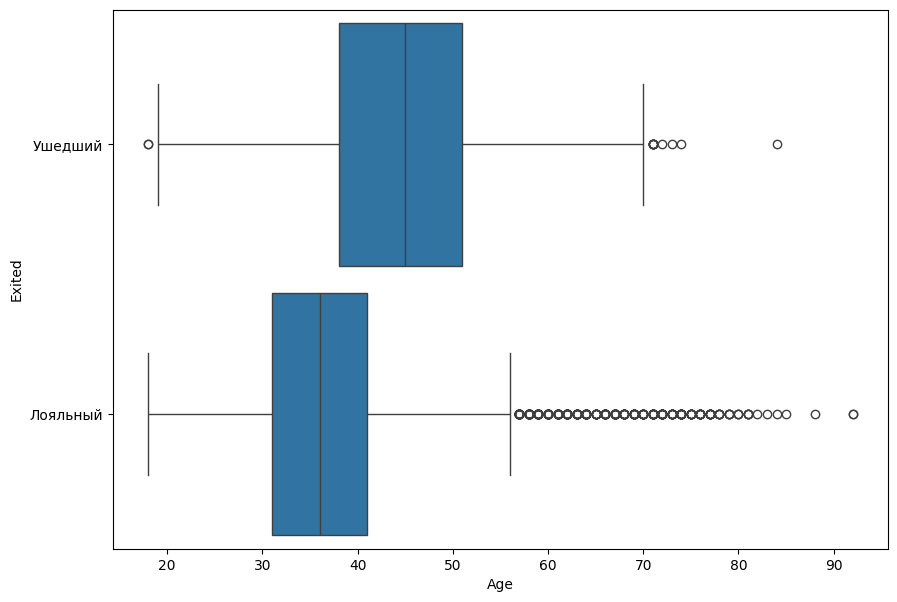

In [114]:
fig_1 = plt.figure(figsize=(10, 7))
boxplot = sns.boxplot(
    data=churn_data,
    y='Exited',
    x='Age',
    orient='h',
    width=0.9
)

Потеницальных выбросов больше всего в группе Лояльных клиентов. Банку следует обратить внимание на клиентов со средним возрастом от 40 до 50 лет, так как именно эта возрастная группа составляет большинство ушедших клиентов.

9.5. Постройте график, который показывает взаимосвязь кредитного рейтинга клиента и его предполагаемой зарплаты. Добавьте расцветку по признаку оттока клиентов. Какова взаимосвязь между признаками? Если не видите явной взаимосвязи, укажите это.

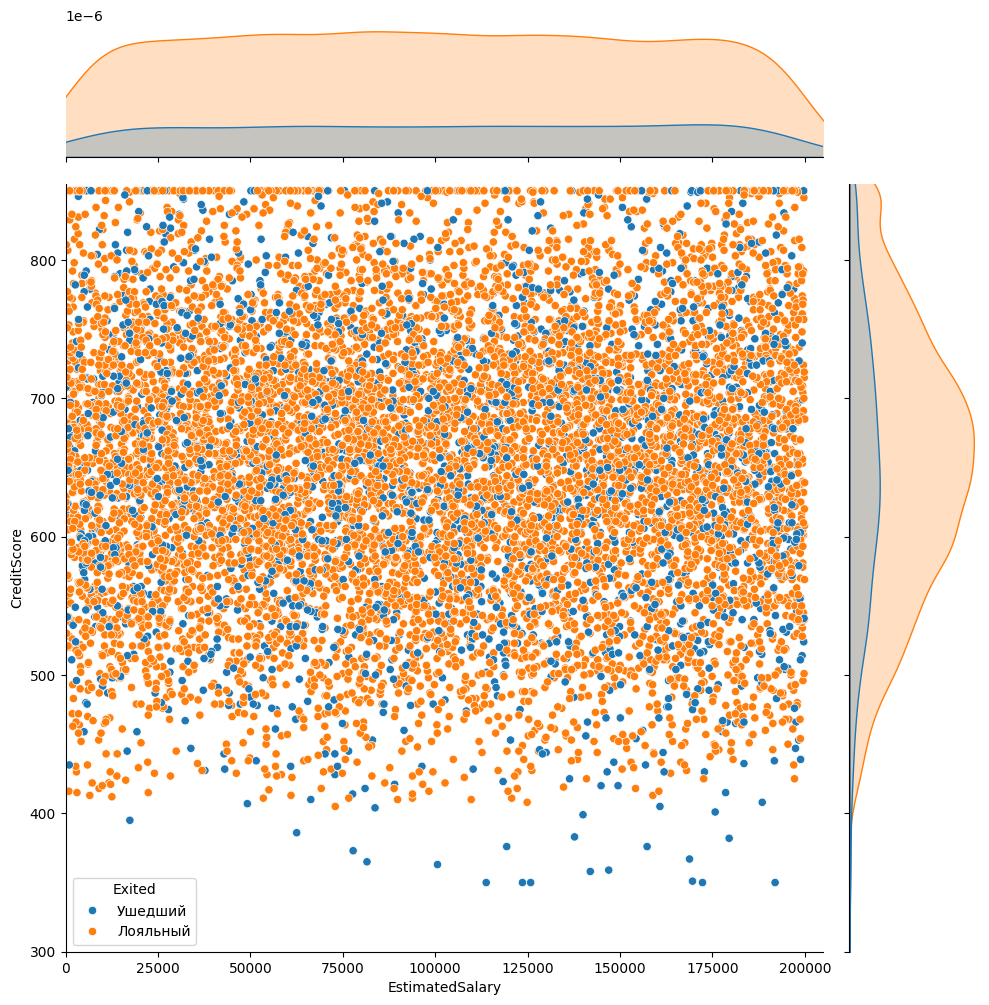

In [115]:
credit_salary_clients = sns.jointplot(
    data=churn_data, 
    x='EstimatedSalary', 
    y='CreditScore',
    hue='Exited',
    xlim = (0, 205000),
    ylim = (300, 855),
    height=10,
)

Каких-либо существенных выводов из представленных данных сделать не представляется возможным. 

9.6. Кто чаще уходит, мужчины или женщины? Постройте график, который иллюстрирует это.

In [117]:
churn_data = pd.read_csv('data/churn.csv')
churn_data = churn_data.drop('RowNumber', axis=1)

grouped_by_gender = churn_data.groupby(['Gender'])['Exited'].mean()
fig = px.bar(
    data_frame=grouped_by_gender,
    x=grouped_by_gender.index,
    y='Exited',
    height=500, #высота
    width=700, #ширина
    title='Доли ушедших клиентов в разрезе пола'
)
fig.show()